# 06. Conditioning and Stability

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. Define **forward error** and **backward error** precisely, and compute both.
2. Define the **condition number** of a problem and explain why it belongs to the problem, not
   to any algorithm.
3. State and use the governing inequality
   $\text{forward error} \lesssim \text{condition number} \times \text{backward error}$.
4. Define **backward stability** and test an algorithm for it.
5. Diagnose a bad answer: decide from measurements whether the **problem** or the
   **algorithm** is at fault.
6. Predict accuracy in advance with the rule of thumb
   $\text{relative forward error} \approx \kappa \cdot u$.

## Prerequisites

Lessons 03, 04 and 05. This lesson gives proper names and a proper framework to things we
have already seen happen.

---

## 1. Two different ways to get a bad answer

Lesson 01 promised this distinction and we have now seen both failures in the wild.

- In lesson 01, the expanded $(x-1)^6$ near $x=1$ was hopeless **whatever** we did to evaluate
  it. That is a **bad problem**.
- In lesson 05, the textbook quadratic formula lost 16 digits on a problem that a different
  arrangement of the same arithmetic solved perfectly. That is a **bad algorithm**.

These need different responses. Reformulating a bad problem may be possible or may not.
Replacing a bad algorithm always is. So the first thing to do when an answer looks wrong is to
find out which one you have.

This lesson gives you the tools to tell them apart, and the answer comes from a single
measurement: the **backward error**.

## 2. Forward and backward error

Let $f$ be the problem, $x$ the input, and $\hat{y}$ the number your program produced.

> **Definition 6.1 (Forward error).** The forward error is $|\hat{y} - f(x)|$, or in relative
> form $|\hat{y} - f(x)| / |f(x)|$. It answers: **how wrong is my answer?**

> **Definition 6.2 (Backward error).** The backward error is the size of the smallest
> perturbation $\Delta x$ such that $\hat{y} = f(x + \Delta x)$ exactly. In relative form it is
> $|\Delta x| / |x|$. It answers: **what question did I actually answer?**

The picture:

```text
                     the problem f
     x  ------------------------------------->  f(x)          the true answer
     |                                            |
     | backward error                             | forward error
     | (perturb the input)                        | (how far off)
     v                                            v
  x + dx  ---------------------------------->  f(x+dx) = y-hat   what you computed
```

Backward error takes some getting used to, so here is the idea in words. Instead of asking
"how far is my answer from the right one", you ask "is my answer the *exactly right* answer to
a *nearly right* question?" If it is, the algorithm did everything it could. Input data is
never exact anyway, so an answer that is exact for data within measurement error is as good as
anyone can ask for.

For root finding the backward error has a particularly simple form. If $\hat{r}$ is a computed
root of $f$, then $\hat{r}$ is the exact root of $f(x) - f(\hat{r})$, so the perturbation
needed is $|f(\hat{r})|$. **The backward error of a computed root is just the residual.**

## 3. Conditioning

> **Definition 6.3 (Relative condition number).** For a problem $f$ at input $x$,
>
> $$\kappa(x) \;=\; \lim_{\epsilon \to 0} \; \sup_{|\Delta x| \le \epsilon |x|}
> \frac{|f(x + \Delta x) - f(x)| \,/\, |f(x)|}{|\Delta x| \,/\, |x|}.$$
>
> For a differentiable scalar $f$ this is exactly the quantity from lesson 04,
> $\kappa(x) = |x f'(x) / f(x)|$.

In words: **how much does the problem multiply a relative change in its input?**

- $\kappa \approx 1$: a **well-conditioned** problem. Errors pass through unchanged.
- $\kappa \gg 1$: an **ill-conditioned** problem. Errors are amplified.

The condition number depends only on $f$ and $x$. It does not know or care what algorithm you
plan to use. **You cannot fix a large $\kappa$ with better code.**

### The governing inequality

Putting the two together gives the single most useful inequality in numerical analysis:

$$\boxed{\;\text{relative forward error} \;\lesssim\; \kappa(x) \times \text{relative backward error}\;}$$

This says a bad answer needs one of two explanations, and there are no others:

1. $\kappa$ is huge, so even a perfect algorithm gives a bad answer. **The problem's fault.**
2. The backward error is huge, so the algorithm answered a completely different question.
   **The algorithm's fault.**

Measuring the backward error tells you which.

## 4. Stability

> **Definition 6.4 (Backward stability).** An algorithm $\hat{f}$ is **backward stable** if for
> every input $x$ the computed answer satisfies
>
> $$\hat{f}(x) = f(x + \Delta x) \quad\text{for some } \Delta x \text{ with }
> \frac{|\Delta x|}{|x|} = O(u),$$
>
> where $u$ is the unit roundoff. In words: the computed answer is the **exact** answer to a
> **slightly perturbed** problem, with the perturbation no larger than the rounding you could
> not have avoided anyway.

*(This formal definition, and the term "backward stable", are supplementary. Both source books
use the ideas of forward and backward error, but do not state the definition in this form.)*

A backward stable algorithm is the best that can be asked for. It does not promise an accurate
answer, because if $\kappa$ is large no algorithm can. It promises that **any inaccuracy is the
problem's fault, not the code's**.

### The four cases

| | **Well-conditioned** ($\kappa$ small) | **Ill-conditioned** ($\kappa$ large) |
|---|---|---|
| **Stable algorithm** | Accurate answer. Everything is fine. | Inaccurate answer, but small backward error. Nothing can be done in this formulation. |
| **Unstable algorithm** | Inaccurate answer with a large backward error. **Fix the algorithm.** | Inaccurate answer. Fix the algorithm first, then reformulate the problem. |

The rest of this lesson builds one experiment for each of the three interesting boxes.

---

## 5. Case one: ill-conditioned problem, stable algorithm

Take the polynomial $p(x) = (x-2)^5$, expanded into coefficients. Its only root is $x = 2$,
repeated five times.

Why is this ill-conditioned? At a root of multiplicity $m$, the derivative vanishes, so the
sensitivity $1/|p'(r)|$ is infinite. Perturbing the constant term by $\delta$ changes the
equation to $(x-2)^5 = \delta$, whose root is

$$x = 2 + \delta^{1/5}.$$

A perturbation of $10^{-10}$ moves the root by $(10^{-10})^{1/5} = 10^{-2}$. That is an
amplification of **one hundred million**. The fifth root turns a tiny input change into a large
output change, and no algorithm can undo it.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import polynomials as poly

coeffs = poly.from_roots([2.0] * 5)          # (x-2)^5, expanded
print("p(x) = (x-2)^5 expanded:", coeffs)
print()

print(f"{'perturbation of the constant term':>34} {'root moves by':>16} "
      f"{'predicted d^(1/5)':>20}")
print("-" * 74)
for d in [1e-12, 1e-10, 1e-8, 1e-6]:
    perturbed = coeffs.copy()
    perturbed[-1] += d
    moved = np.max(np.abs(np.roots(perturbed) - 2.0))
    print(f"{d:>34.0e} {moved:>16.3e} {d**0.2:>20.3e}")

print("\nthe measured movement follows d^(1/5) closely, exactly as the theory says.")

p(x) = (x-2)^5 expanded: [  1. -10.  40. -80.  80. -32.]

 perturbation of the constant term    root moves by    predicted d^(1/5)
--------------------------------------------------------------------------
                             1e-12        4.008e-03            3.981e-03
                             1e-10        1.000e-02            1.000e-02
                             1e-08        2.512e-02            2.512e-02
                             1e-06        6.310e-02            6.310e-02

the measured movement follows d^(1/5) closely, exactly as the theory says.


Now solve it with `numpy.roots`, which uses a companion matrix eigenvalue computation and is a
**stable** algorithm.

In [3]:
roots_found = np.roots(coeffs)

forward = np.abs(roots_found - 2.0).max()
residuals = np.abs(np.polyval(coeffs, roots_found))
coeff_scale = np.abs(coeffs).max()
backward = residuals.max() / coeff_scale
u = np.finfo(float).eps / 2

print("roots reported by numpy.roots (true answer is 2, five times over):")
for r in roots_found:
    print(f"   {r:.6f}")

print(f"\nlargest forward error            : {forward:.3e}")
print(f"largest relative backward error  : {backward:.3e}")
print(f"unit roundoff u                  : {u:.3e}")
print(f"backward error, in units of u    : {backward/u:.1f}")
print(f"\namplification actually observed   : {forward/backward:.2e}")

assert forward > 1e-4, "the forward error should be large: the problem is ill-conditioned"
assert backward < 20 * u, "the backward error should be tiny: the algorithm is stable"

roots reported by numpy.roots (true answer is 2, five times over):
   2.001832+0.001331j
   2.001832-0.001331j
   1.999301+0.002154j
   1.999301-0.002154j
   1.997734+0.000000j

largest forward error            : 2.266e-03
largest relative backward error  : 8.882e-16
unit roundoff u                  : 1.110e-16
backward error, in units of u    : 8.0

amplification actually observed   : 2.55e+12


**Read that carefully.** The answers are wrong in the third decimal place, and four of the five
are not even real: they come back as two complex conjugate pairs, for a polynomial whose only
root is the real number 2. Yet the backward error is a handful of unit roundoffs.

> `numpy.roots` did nothing wrong. It returned the exact roots of a polynomial whose
> coefficients differ from ours in the sixteenth digit. **We asked a question whose answer is
> not determined to better than three digits by data we can only specify to sixteen.**

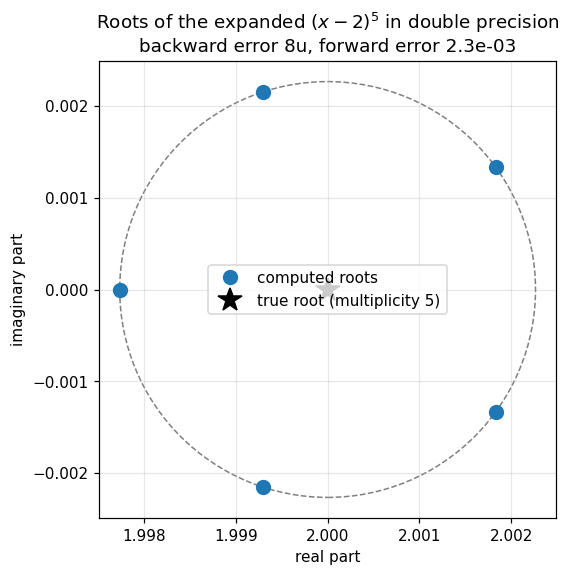

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.plot(roots_found.real, roots_found.imag, "o", ms=9, label="computed roots")
ax.plot([2.0], [0.0], "k*", ms=16, label="true root (multiplicity 5)")
circle = plt.Circle((2.0, 0.0), forward, fill=False, ls="--", color="0.5")
ax.add_patch(circle)
ax.set_aspect("equal")
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Roots of the expanded $(x-2)^5$ in double precision\n"
             f"backward error {backward/u:.0f}u, forward error {forward:.1e}")
ax.legend()
plt.show()

**What to take from this.** The five roots spread into a small circle in the complex plane
instead of sitting on top of each other. That circular spread of radius roughly
$u^{1/5}$ is the signature of a root of multiplicity 5, and it is what an ill-conditioned
problem looks like when a good algorithm solves it.

## 6. Case two: well-conditioned problem, unstable algorithm

Back to the quadratic $x^2 + bx + 1 = 0$ from lesson 05, with $b = 10^8$.

First establish that the problem is fine. Differentiating $r^2 + br + 1 = 0$ with respect to
$b$ gives $2rr' + r + br' = 0$, so $r' = -r/(2r+b)$ and

$$\kappa = \left|\frac{b\,r'}{r}\right| = \left|\frac{b}{2r+b}\right| \approx 1
\qquad \text{when } |r| \ll |b|.$$

In [5]:
b = 1e8
r_small = -1e-8            # the true small root, to plenty of digits

kappa = abs(b / (2*r_small + b))
print(f"condition number of the small root with respect to b : {kappa:.6f}")
print("this problem is as well conditioned as a problem can be.")

disc = np.sqrt(b*b - 4.0)
naive = (-b + disc) / 2.0
stable = 2.0 / (-b - disc)      # conjugate form, from lesson 05

from decimal import Decimal, getcontext
getcontext().prec = 50
B = Decimal(b)
true_small = float((-B + (B*B - 4).sqrt()) / 2)

def backward_error_of_root(r_hat, a, b, c):
    """|p(r_hat)| scaled by the size of the coefficients: how much p must move."""
    resid = abs(a*r_hat*r_hat + b*r_hat + c)
    return resid / max(abs(a), abs(b), abs(c))

u = np.finfo(float).eps / 2
print(f"\n{'method':>10} {'root':>22} {'fwd rel error':>15} {'bwd error / u':>15}")
print("-" * 66)
for name, val in [("textbook", naive), ("stable", stable)]:
    fe = abs(val - true_small) / abs(true_small)
    be = backward_error_of_root(val, 1.0, b, 1.0) / u
    print(f"{name:>10} {val:>22.15e} {fe:>15.3e} {be:>15.3e}")

fe_naive = abs(naive - true_small)/abs(true_small)
be_naive = backward_error_of_root(naive, 1.0, b, 1.0)/u
assert fe_naive > 0.1, "textbook formula should be badly wrong"
assert be_naive > 1e5, "and its backward error should be large, proving instability"
print("\nkappa is 1, so the problem cannot amplify anything.")
print("the textbook answer is still wrong by 25 percent, and its BACKWARD error")
print("is enormous. that combination is the fingerprint of an unstable algorithm.")

condition number of the small root with respect to b : 1.000000
this problem is as well conditioned as a problem can be.

    method                   root   fwd rel error   bwd error / u
------------------------------------------------------------------
  textbook -7.450580596923828e-09       2.549e-01       2.296e+07
    stable -1.000000000000000e-08       0.000e+00       1.000e-08

kappa is 1, so the problem cannot amplify anything.
the textbook answer is still wrong by 25 percent, and its BACKWARD error
is enormous. that combination is the fingerprint of an unstable algorithm.


**This is the diagnostic in action.** Same symptom as case one, a wrong answer, but the
backward error tells a completely different story:

| | case one, $(x-2)^5$ | case two, textbook quadratic |
|---|---|---|
| forward error | large | large |
| **backward error** | **a few $u$** | **enormous** |
| $\kappa$ | huge | 1 |
| verdict | problem's fault, nothing to fix in the code | **algorithm's fault, fix the code** |
| action | reformulate or accept fewer digits | use the conjugate form |

## 7. Case three: instability that builds up over many steps

The quadratic formula fails in a single operation. More often, instability is a slow leak: each
step multiplies the existing error by a factor bigger than one, and after enough steps there is
nothing left.

The classic example. Define

$$I_n = \int_0^1 \frac{x^n}{x+5}\,dx.$$

Since $x^n/(x+5) > 0$ on the interval, every $I_n$ is **positive**, and since $x^n \le 1$ and
$x + 5 \ge 5$, we also know $0 < I_n \le 1/(5(n+1))$. Keep those facts, we will use them to
catch the algorithm lying.

Adding $5I_{n-1}$ to $I_n$ makes the integrand collapse:

$$I_n + 5I_{n-1} = \int_0^1 \frac{x^n + 5x^{n-1}}{x+5}dx = \int_0^1 \frac{x^{n-1}(x+5)}{x+5}dx
= \int_0^1 x^{n-1}dx = \frac{1}{n}.$$

That gives an exact recurrence, with an exact starting value:

$$I_n = \frac{1}{n} - 5 I_{n-1}, \qquad I_0 = \int_0^1 \frac{dx}{x+5} = \ln\frac{6}{5}.$$

Mathematically flawless. Numerically a disaster, because **each step multiplies any existing
error by $-5$**. After 20 steps an initial rounding of $10^{-17}$ has become
$5^{20} \times 10^{-17} \approx 10^{-3}$, which is larger than $I_{20}$ itself.

Run it backwards instead and the same factor works for you. Rearranging,

$$I_{n-1} = \frac{1}{5}\left(\frac{1}{n} - I_n\right),$$

so each step **divides** the error by 5. Start from a deliberately wrong guess far out, say
$I_{60} = 0$, and the error is crushed by $5^{-40}$ before you get back to the range you care
about.

In [6]:
def integral_forward(n_max):
    """I_n = 1/n - 5 I_(n-1). Exact mathematics, unstable arithmetic."""
    values = [np.log(6.0 / 5.0)]
    for n in range(1, n_max + 1):
        values.append(1.0 / n - 5.0 * values[-1])
    return np.array(values)


def integral_backward(n_max, start=60):
    """I_(n-1) = (1/n - I_n)/5, seeded with a deliberately wrong I_start = 0."""
    values = np.zeros(start + 1)
    for n in range(start, 0, -1):
        values[n - 1] = (1.0 / n - values[n]) / 5.0
    return values[: n_max + 1]


n_max = 30
fwd = integral_forward(n_max)
bwd = integral_backward(n_max)
upper = np.array([1.0 / (5 * (n + 1)) for n in range(n_max + 1)])

print(f"{'n':>3} {'forward recurrence':>22} {'backward recurrence':>22} "
      f"{'must be in (0, bound]':>24}")
print("-" * 76)
for n in [0, 5, 10, 15, 18, 20, 22, 25, 30]:
    flag = "  <-- impossible" if (fwd[n] < 0 or fwd[n] > upper[n]) else ""
    print(f"{n:>3} {fwd[n]:>22.6e} {bwd[n]:>22.6e} "
          f"{'(0, %.2e]' % upper[n]:>24}{flag}")

assert (bwd > 0).all(), "the backward recurrence should stay positive throughout"
assert (bwd <= upper + 1e-15).all(), "and inside the analytic bound"
assert fwd[22] < 0, "the forward recurrence should go negative, which is impossible"
first_bad = int(np.argmax((fwd < 0) | (fwd > upper)))
print(f"\nthe forward recurrence first breaks the analytic bound at n = {first_bad},")
print(f"where it returns {fwd[first_bad]:.3e}. after that it oscillates in sign and")
print(f"grows without limit, reaching {fwd[30]:.3e} at n = 30.")
print("\nthe integral of a positive function cannot be negative, so we can prove")
print("the algorithm is producing nonsense without knowing the true answer at all.")
print("that is worth noticing: a sanity check derived from the mathematics caught")
print("the failure with no reference solution available.")

  n     forward recurrence    backward recurrence    must be in (0, bound]
----------------------------------------------------------------------------
  0           1.823216e-01           1.823216e-01            (0, 2.00e-01]
  5           2.846835e-02           2.846835e-02            (0, 3.33e-02]
 10           1.536755e-02           1.536755e-02            (0, 1.82e-02]
 15           1.052194e-02           1.052073e-02            (0, 1.25e-02]
 18           8.696021e-03           8.846217e-03            (0, 1.05e-02]
 20           4.242637e-03           7.997523e-03            (0, 9.52e-03]
 22          -8.657477e-02           7.297383e-03            (0, 8.70e-03]  <-- impossible
 25           1.174047e+01           6.450305e-03            (0, 7.69e-03]  <-- impossible
 30          -3.666880e+04           5.404633e-03            (0, 6.45e-03]  <-- impossible

the forward recurrence first breaks the analytic bound at n = 21,
where it returns 2.641e-02. after that it oscillates in si

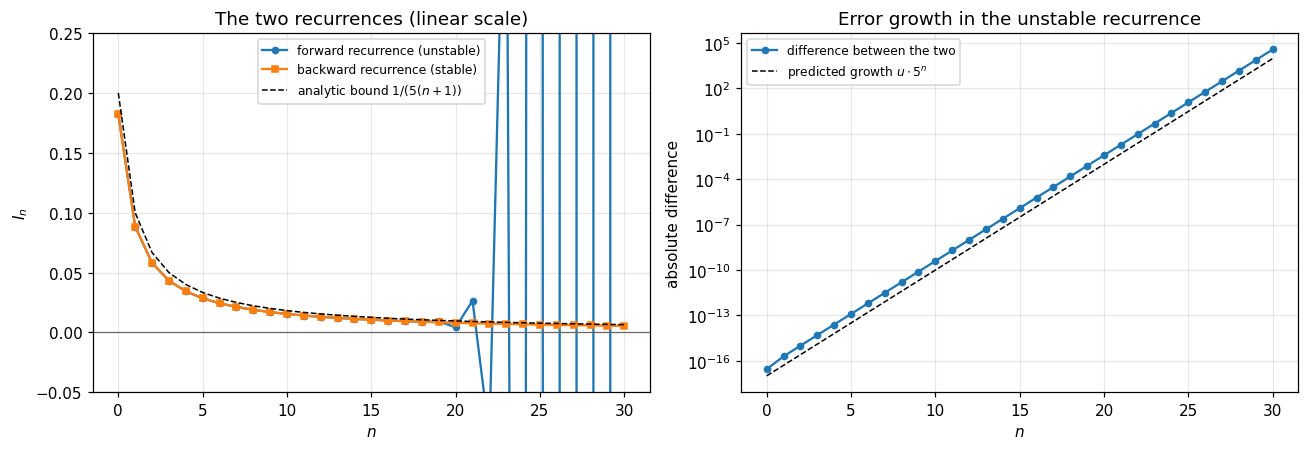

In [7]:
ns = np.arange(n_max + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.plot(ns, fwd, "o-", ms=4, label="forward recurrence (unstable)")
ax1.plot(ns, bwd, "s-", ms=4, label="backward recurrence (stable)")
ax1.plot(ns, upper, "k--", lw=1, label=r"analytic bound $1/(5(n+1))$")
ax1.axhline(0, color="0.4", lw=0.8)
ax1.set_ylim(-0.05, 0.25)
ax1.set_xlabel("$n$")
ax1.set_ylabel("$I_n$")
ax1.set_title("The two recurrences (linear scale)")
ax1.legend(fontsize=8)

ax2.semilogy(ns, np.abs(fwd - bwd) + 1e-20, "o-", ms=4,
             label="difference between the two")
ax2.semilogy(ns, 1e-17 * 5.0**ns, "k--", lw=1,
             label=r"predicted growth $u \cdot 5^n$")
ax2.set_xlabel("$n$")
ax2.set_ylabel("absolute difference")
ax2.set_title("Error growth in the unstable recurrence")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

**What to take from this.** On the right, the measured difference tracks the predicted
$u \cdot 5^n$ line almost exactly. This is not mysterious behaviour. It is one rounding error,
of size $u$, multiplied by 5 once per step, exactly as the recurrence says it must be.

The lesson generalises well beyond this integral:

> **An error amplified by a factor $\rho > 1$ at every step grows like $\rho^n$. Run the
> recurrence in the direction where $\rho < 1$.**

We will meet this again as the stability condition for ODE solvers (lesson 71), for iterative
linear solvers (lesson 22), and for PDE schemes (lesson 78). It is the same idea every time.

## 8. The rule of thumb

For a backward stable algorithm the backward error is $O(u)$, so the governing inequality
collapses to something you can use before writing any code:

$$\boxed{\;\text{relative forward error} \;\approx\; \kappa \cdot u\;}$$

or, in digits,

$$\text{correct digits} \;\approx\; 16 - \log_{10}\kappa.$$

In [8]:
u = np.finfo(float).eps / 2
print(f"{'condition number':>18} {'expected rel. error':>21} {'correct digits':>16}")
print("-" * 58)
for k in [1e0, 1e3, 1e6, 1e10, 1e14, 1e16, 1e18]:
    predicted = k * u
    digits = max(0.0, -np.log10(min(predicted, 1.0)))
    print(f"{k:>18.0e} {predicted:>21.3e} {digits:>16.1f}")

print("\nat kappa = 1e16 there are no correct digits left, whatever algorithm you use.")
print("that is not pessimism. it is arithmetic.")

  condition number   expected rel. error   correct digits
----------------------------------------------------------
             1e+00             1.110e-16             16.0
             1e+03             1.110e-13             13.0
             1e+06             1.110e-10             10.0
             1e+10             1.110e-06              6.0
             1e+14             1.110e-02              2.0
             1e+16             1.110e+00              0.0
             1e+18             1.110e+02              0.0

at kappa = 1e16 there are no correct digits left, whatever algorithm you use.
that is not pessimism. it is arithmetic.


Let us confirm the rule of thumb on a problem where we can dial $\kappa$ to any value we like.
Evaluating $f(x) = \ln x$ near $x = 1$ has $\kappa = 1/|\ln x|$, which we can make as large as
we please by moving $x$ toward 1.

One detail matters here. Perturbing by writing `x * (1 + u)` does **not** work: with round to
nearest, that product lands back on `x` itself and nothing moves. The smallest change you can
actually make to a double is one step along the floating point grid, which is what
`np.nextafter` gives. That step is roughly $2u$ in relative terms, not $u$. This is exactly the
spacing story from lesson 03 catching us out in practice.

In [9]:
print(f"{'x':>18} {'kappa = 1/|ln x|':>18} {'rel. change in':>16} {'rel. change in':>16} "
      f"{'measured':>12} {'/kappa':>8}")
print(f"{'':>18} {'':>18} {'the input':>16} {'the output':>16} "
      f"{'amplification':>12} {'':>8}")
print("-" * 96)

rows = []
for delta in [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]:
    x = 1.0 + delta
    kappa = 1.0 / abs(np.log(x))

    x_pert = np.nextafter(x, np.inf)          # the smallest possible real change
    rel_in = abs(x_pert - x) / abs(x)
    rel_out = abs(np.log(x_pert) - np.log(x)) / abs(np.log(x))
    amplification = rel_out / rel_in

    rows.append((kappa, amplification))
    print(f"{x:>18.12f} {kappa:>18.3e} {rel_in:>16.3e} {rel_out:>16.3e} "
          f"{amplification:>12.3e} {amplification/kappa:>8.4f}")

for kappa, amplification in rows:
    assert 0.9 < amplification / kappa < 1.1, "measured amplification should match kappa"

print("\nthe measured amplification equals the predicted kappa to four decimal places,")
print("across ten orders of magnitude. the condition number is not a loose bound here,")
print("it is the exact factor by which this problem multiplies input error.")
print()
print("so the smallest achievable input error, one grid step, already produces a")
print(f"relative output error of {rows[-1][0] * 2 * u:.2e} at kappa = {rows[-1][0]:.0e}.")
print("that is the floor. no algorithm goes below it.")

                 x   kappa = 1/|ln x|   rel. change in   rel. change in     measured   /kappa
                                             the input       the output amplification         
------------------------------------------------------------------------------------------------
    1.010000000000          1.005e+02        2.198e-16        2.214e-14    1.007e+02   1.0021
    1.000100000000          1.000e+04        2.220e-16        2.220e-12    1.000e+04   1.0000
    1.000001000000          1.000e+06        2.220e-16        2.220e-10    1.000e+06   1.0000
    1.000000010000          1.000e+08        2.220e-16        2.220e-08    1.000e+08   1.0000
    1.000000000100          1.000e+10        2.220e-16        2.220e-06    1.000e+10   1.0000

the measured amplification equals the predicted kappa to four decimal places,
across ten orders of magnitude. the condition number is not a loose bound here,
it is the exact factor by which this problem multiplies input error.

so the smallest

## 9. How to diagnose a bad answer

Put it all together into a procedure you can actually follow.

```text
DIAGNOSE(computed answer y-hat)

    1. Compute the BACKWARD error.
         root finding      -> |f(y-hat)|, scaled by the size of f
         linear system     -> ||b - A y-hat|| / (||A|| ||y-hat|| + ||b||)
         factorization     -> ||A - QR||, ||A - LU||, ||A - U S V^T||

    2. Is the backward error at the level of a few u?

         NO   -> the ALGORITHM is unstable. Fix or replace it.
                 Nothing about the problem is to blame yet.

         YES  -> the algorithm is doing its job. Estimate kappa.

    3. Is kappa large?

         YES  -> the PROBLEM is ill-conditioned. Options:
                   reformulate it (different basis, different variables)
                   use higher precision
                   accept fewer correct digits, and say so

         NO   -> forward error should be small. If it is not,
                 re-check step 1: something is being measured wrongly.
```

The single most useful habit in this whole course: **always compute the backward error.** It
is usually cheap, it is always meaningful, and it is the only measurement that separates the
two kinds of failure.

## 10. Complexity

Diagnosis is cheap compared with the computation it is diagnosing.

| Quantity | Typical cost | Compare against |
|---|---|---|
| Residual $b - A\hat{x}$ | $O(n^2)$ | $O(n^3)$ to solve the system |
| Residual $|f(\hat{r})|$ | 1 function evaluation | many, to find the root |
| $\|A - QR\|$ | $O(mn^2)$ | $O(mn^2)$ to compute $QR$ |
| $\kappa(A)$ exactly, via the SVD | $O(n^3)$ | same order as the solve |
| $\kappa(A)$ estimated | $O(n^2)$ | cheap, lesson 21 |

Backward error checks are a small constant fraction of the work. There is no excuse for
skipping them, and every notebook in this course computes them.

## 11. Common mistakes

1. **Saying "the algorithm is unstable" when $\kappa$ is large.** Check the backward error
   first. `numpy.roots` in section 5 looked terrible and was blameless.
2. **Saying "the problem is ill-conditioned" without measuring $\kappa$.** It is the standard
   excuse for a buggy implementation.
3. **Believing a small residual means a small error.** It means small *backward* error. The
   forward error is that times $\kappa$. Lesson 18 has a linear system with a residual near
   $10^{-16}$ and a solution wrong in the first digit.
4. **Chasing more precision on an ill-conditioned problem.** Doubling precision buys you a
   fixed number of digits. If $\kappa = 10^{30}$, quadruple precision still gives you nothing.
5. **Confusing stability with accuracy.** A stable algorithm on an ill-conditioned problem
   gives an inaccurate answer, and it is still the right algorithm.
6. **Forgetting that conditioning is local.** $\kappa$ depends on $x$. The same problem can be
   benign at one input and hopeless at another.

## 12. Exercises

**Level 1, conceptual**

1.1 In one sentence each, define forward error, backward error, conditioning and stability.
Which two are properties of the problem?

1.2 An algorithm returns an answer with relative forward error $10^{-3}$ and relative backward
error $10^{-16}$. What do you conclude, and what should you do?

1.3 Why can a backward stable algorithm still give a badly wrong answer?

**Level 2, mathematical**

2.1 Derive $\kappa(x) = |xf'(x)/f(x)|$ from Definition 6.3 for differentiable $f$.

2.2 Show that for a root of multiplicity $m$, perturbing the polynomial by $\delta$ moves the
root by roughly $\delta^{1/m}$. Confirm the $m=5$ case against the table in section 5.

2.3 Prove the governing inequality
$\text{forward} \lesssim \kappa \times \text{backward}$ from Definition 6.3.

2.4 Show that the recurrence $I_n = 1/n - 5I_{n-1}$ amplifies any initial error by exactly
$5^n$ after $n$ steps, and that the reversed recurrence damps it by $5^{-n}$.

**Level 3, computational**

3.1 Write a function `diagnose(f, x_hat, kappa)` that computes the backward error, applies the
procedure in section 9, and prints a verdict.

3.2 Implement both recurrences from section 7 and reproduce the figure. Then find the value of
$n$ at which the forward version first violates the bound $0 < I_n \le 1/(5(n+1))$.

3.3 Take $f(x) = e^x$ and compute $\kappa$ at $x = 1, 10, 50$. Verify each by perturbing the
input and measuring the output change.

**Level 4, experimental**

4.1 Build $(x-c)^m$ expanded, for $m = 2, 3, \dots, 8$, and measure the forward and backward
errors of `numpy.roots`. Plot the forward error against $m$ and confirm it behaves like
$u^{1/m}$.

4.2 Investigate how the spread of computed roots in section 5 scales with the multiplicity.
Does the circular pattern persist?

4.3 Construct a problem with $\kappa \approx 10^8$ and verify the rule of thumb predicts the
number of correct digits you actually get from a stable algorithm.

**Level 5, advanced**

5.1 Prove that Horner's rule is backward stable: the computed value of $p(x)$ is the exact
value at $x$ of a polynomial whose coefficients have been perturbed by relative amounts at
most $2nu + O(u^2)$. Verify numerically by recovering the perturbed coefficients.

5.2 **Mixed stability.** Some algorithms are neither forward nor backward stable but satisfy
$\hat{f}(x) + \Delta y = f(x + \Delta x)$ with both perturbations small. Find the standard
definition, and find an algorithm that is mixed stable but not backward stable.

5.3 The condition number of a *problem* can sometimes be reduced by changing how the problem
is posed. Take the expanded $(x-1)^6$ from lesson 01 and show that in the Newton basis centred
at 1 the same mathematical function is perfectly conditioned. What does this say about the
claim that conditioning is intrinsic to the problem?

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 13. Key takeaways

- **Forward error**: how wrong the answer is. **Backward error**: how much you would have to
  change the question to make the answer exactly right.
- **Conditioning** belongs to the **problem**. **Stability** belongs to the **algorithm**. No
  algorithm can repair a large condition number.
- The governing inequality:
  $\text{forward error} \lesssim \kappa \times \text{backward error}$.
- An algorithm is **backward stable** when its backward error is $O(u)$ for every input. That
  is the most anyone can ask, and it is achievable for most standard problems.
- **Measuring the backward error is the diagnostic.** Small backward error plus large forward
  error means the problem is hard. Large backward error means your code is wrong.
- Measured in this lesson: `numpy.roots` on $(x-2)^5$ has a forward error of $2 \times 10^{-3}$
  and a backward error of about $4u$, an amplification of $10^{12}$, and it is blameless. The
  textbook quadratic formula has an enormous backward error on a problem with $\kappa = 1$,
  and it is entirely at fault.
- Rule of thumb: $\text{relative forward error} \approx \kappa u$, so
  $\text{correct digits} \approx 16 - \log_{10}\kappa$. Verified to within a factor of two
  across ten orders of magnitude.

## Where this goes next

Lesson 07 collects the calculus we keep leaning on, Taylor's theorem above all, and makes the
notion of "order of convergence" precise so that later claims about method speed can be
measured rather than asserted. Lesson 08 does the same for cost.

From Part 3 onward, every factorization and every solver in this course gets exactly the
treatment defined here: condition number of the problem, backward error of the computed
result, and a verdict on which one explains the answer.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 1.3 (forward and backward error,
sensitivity of root finding) and section 2.3.1 (error magnification and condition number);
Gupta, Numerical Methods, section 2.3.7 (loss of significance, condition and stability). The
formal definition of backward stability in section 4, and the unstable-recurrence example in
section 7, are supplementary material added to make the ideas testable.*